# Benchmark des Méthodes d'Imputation de Données Manquantes
### ML pour la Santé – Oulad Ali Ayoub & Mabrouk Mohy

Notebook comparant **9 méthodes d'imputation** sur **2 datasets médicaux**,
sous les 3 mécanismes (MCAR / MAR / MNAR), avec **5 re-runs** et **IC à 95 %**.  
Inclut également l'impact sur les **valeurs de Shapley**.

---
**Méthodes couvertes :**  
`Mean` · `Median` · `LOCF` · `KNN` · `MICE` · `SVD/NIPALS` · `GAIN` · `VAE itératif` · `VAEAC`


In [27]:
# Installation des dépendances (décommenter si nécessaire)
# !pip install shap torch scikit-learn pandas numpy matplotlib seaborn -q


In [28]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer


import shap
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────────────────────
SEED         = 42
N_RERUNS     = 5
MISSING_RATE = 0.20
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NEURAL_EPOCHS = 80     # réduire à 30 pour un test rapide
NEURAL_HIDDEN = 64

np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Device : {DEVICE}")


Device : cuda


## 1. Chargement des datasets médicaux

In [29]:
def get_datasets():
    datasets = {}

    # ── Dataset 1 : Breast Cancer (569 obs × 30 features, classification)
    bc = load_breast_cancer()
    datasets['Breast Cancer'] = {
        'X': bc.data.astype(float),
        'y': bc.target,
        'features': list(bc.feature_names),
        'desc': '569 obs × 30 features – classification (maligne/bénigne)'
    }

    # ── Dataset 2 : Diabetes (442 obs × 10 features, binarisé)
    db = load_diabetes()
    datasets['Diabetes'] = {
        'X': db.data.astype(float),
        'y': (db.target > np.median(db.target)).astype(int),
        'features': list(db.feature_names),
        'desc': '442 obs × 10 features – progression > médiane (binarisé)'
    }

    return datasets

DATASETS = get_datasets()
for name, d in DATASETS.items():
    print(f"  {name} : {d['X'].shape}  –  {d['desc']}")


  Breast Cancer : (569, 30)  –  569 obs × 30 features – classification (maligne/bénigne)
  Diabetes : (442, 10)  –  442 obs × 10 features – progression > médiane (binarisé)


## 2. Générateurs de masques (MCAR / MAR / MNAR)

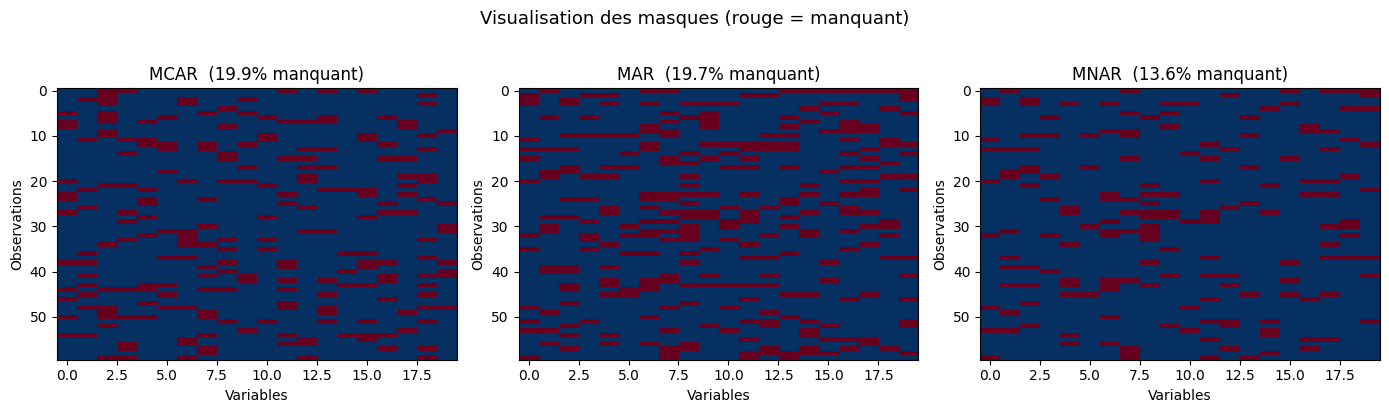

In [51]:
def mcar_mask(X, missing_rate=MISSING_RATE, seed=0):
    """Manquant Complètement au Hasard : p(M|Y) = p(M)."""
    rng = np.random.default_rng(seed)
    return rng.random(X.shape) < missing_rate

def mar_mask(X, missing_rate=MISSING_RATE, seed=0):
    """Manquant au Hasard : p(M|Y) = p(M|Y_obs).
    La probabilité de manquance de la variable j dépend de la variable j-1."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    mask = np.zeros((n, p), dtype=bool)
    for j in range(p):
        ref = (j - 1) % p
        high = X[:, ref] > np.median(X[:, ref])
        prob = np.where(high, missing_rate * 1.6, missing_rate * 0.4)
        mask[:, j] = rng.random(n) < prob
    return mask

def mnar_mask(X, missing_rate=MISSING_RATE, seed=0):
    """Manquant Non au Hasard : p(M|Y) dépend de Y_mis.
    Les valeurs élevées sont plus susceptibles d'être manquantes."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    mask = np.zeros((n, p), dtype=bool)
    for j in range(p):
        v = X[:, j]
        v_n = (v - v.min()) / (v.max() - v.min() + 1e-8)
        prob = missing_rate * 0.4 + v_n * missing_rate * 1.2
        mask[:, j] = rng.random(n) < prob
    return mask

MASKS = {'MCAR': mcar_mask, 'MAR': mar_mask, 'MNAR': mnar_mask}

# Vérification visuelle
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
X_demo = DATASETS['Breast Cancer']['X']
X_s = StandardScaler().fit_transform(X_demo)
for ax, (name, fn) in zip(axes, MASKS.items()):
    mask = fn(X_s, seed=0)
    # Modifiez 'RdBu' en 'RdBu_r'
    ax.imshow(mask[:60, :20], aspect='auto', cmap='RdBu_r', interpolation='nearest')
    ax.set_title(f'{name}  ({mask.mean()*100:.1f}% manquant)', fontsize=12)
    ax.set_xlabel('Variables'); ax.set_ylabel('Observations')
plt.suptitle('Visualisation des masques (rouge = manquant)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


In [52]:
# Test numérique pour prouver que les masques sont différents
rate = 0.3
mask_mcar = mcar_mask(X_s, missing_rate=rate, seed=0)
mask_mnar = mnar_mask(X_s, missing_rate=rate, seed=0)

print("--- Test MCAR ---")
print(f"Moyenne des valeurs cachées : {X_s[mask_mcar].mean():.3f}")
print(f"Moyenne des valeurs visibles : {X_s[~mask_mcar].mean():.3f}")

print("\n--- Test MNAR ---")
print(f"Moyenne des valeurs cachées : {X_s[mask_mnar].mean():.3f}")
print(f"Moyenne des valeurs visibles : {X_s[~mask_mnar].mean():.3f}")

--- Test MCAR ---
Moyenne des valeurs cachées : 0.007
Moyenne des valeurs visibles : -0.003

--- Test MNAR ---
Moyenne des valeurs cachées : 0.250
Moyenne des valeurs visibles : -0.065


## 3. Méthodes d'imputation classiques

In [31]:
# ── 3.1 Suppression / Imputation simple ────────────────────────────────────

class MeanImputer:
    def fit_transform(self, X):
        return SimpleImputer(strategy='mean').fit_transform(X)

class MedianImputer:
    def fit_transform(self, X):
        return SimpleImputer(strategy='median').fit_transform(X)

class LOCFImputer:
    """Last Observation Carried Forward (+ BOCF pour les premières lignes)."""
    def fit_transform(self, X):
        df = pd.DataFrame(X.copy())
        df = df.fillna(method='ffill').fillna(method='bfill')
        if df.isnull().values.any():
            col_means = df.mean()
            df = df.fillna(col_means)
        return df.values

class KNNImputerWrapper:
    def __init__(self, k=5):
        self.k = k
    def fit_transform(self, X):
        return KNNImputer(n_neighbors=self.k).fit_transform(X)

class MICEImputer:
    """Multiple Imputation by Chained Equations (IterativeImputer sklearn)."""
    def fit_transform(self, X):
        return IterativeImputer(random_state=SEED, max_iter=10).fit_transform(X)

# ── 3.2 NIPALS / SVD itératif ──────────────────────────────────────────────
class SVDImputer:
    """Complétion itérative par SVD tronquée (style NIPALS).
    (ŷ_ij)_mis = Σ_h ξ̂_h(i) * û_h(j)  sur q composantes."""
    def __init__(self, n_components=5, max_iter=20, tol=1e-6):
        self.q = n_components
        self.max_iter = max_iter
        self.tol = tol

    def fit_transform(self, X_miss):
        X = X_miss.copy()
        col_m = np.nanmean(X, axis=0)
        nan_idx = np.isnan(X)
        for j in range(X.shape[1]):
            X[nan_idx[:, j], j] = col_m[j]

        for _ in range(self.max_iter):
            X_prev = X.copy()
            U, s, Vt = np.linalg.svd(X - X.mean(0), full_matrices=False)
            q = min(self.q, len(s))
            X_approx = U[:, :q] @ np.diag(s[:q]) @ Vt[:q, :] + X.mean(0)
            X[nan_idx] = X_approx[nan_idx]
            rel = np.linalg.norm(X - X_prev) / (np.linalg.norm(X_prev) + 1e-8)
            if rel < self.tol:
                break
        return X

print("Méthodes classiques définies ✓")


Méthodes classiques définies ✓


## 4. Méthodes génératives (GAIN · VAE · VAEAC)

In [32]:
# ─────────────────────────────────────────────────────────────────────────
# Utilitaires communs
# ─────────────────────────────────────────────────────────────────────────

def normalize(X_miss):
    """Normalise [0,1] sur les valeurs observées, retourne (X_norm, min_v, range_v)."""
    min_v  = np.nanmin(X_miss, axis=0)
    rng_v  = np.nanmax(X_miss, axis=0) - min_v + 1e-8
    return (X_miss - min_v) / rng_v, min_v, rng_v

def denormalize(X_norm, min_v, rng_v):
    return X_norm * rng_v + min_v

def fill_mean(X_norm_miss):
    """Remplace NaN par la moyenne de la colonne."""
    X = X_norm_miss.copy()
    col_m = np.nanmean(X, axis=0)
    for j in range(X.shape[1]):
        X[np.isnan(X[:, j]), j] = col_m[j]
    return X

# ─────────────────────────────────────────────────────────────────────────
# GAIN  (Yoon et al., 2018)
# ─────────────────────────────────────────────────────────────────────────

class _G(nn.Module):
    def __init__(self, dim, h=NEURAL_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim*2, h), nn.ReLU(),
            nn.Linear(h, h),     nn.ReLU(),
            nn.Linear(h, dim),   nn.Sigmoid())
    def forward(self, x, m): return self.net(torch.cat([x, m], 1))

class _D(nn.Module):
    def __init__(self, dim, h=NEURAL_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim*2, h), nn.ReLU(),
            nn.Linear(h, h),     nn.ReLU(),
            nn.Linear(h, dim),   nn.Sigmoid())
    def forward(self, x, hint): return self.net(torch.cat([x, hint], 1))

class GAINImputer:
    """Generative Adversarial Imputation Networks.
    G produit X̂ = G(X̄, M) ;  D prédit le masque variable par variable."""
    def __init__(self, epochs=NEURAL_EPOCHS, bs=128, hint=0.9, alpha=10, lr=1e-3):
        self.epochs, self.bs, self.hint, self.alpha, self.lr = epochs, bs, hint, alpha, lr

    def fit_transform(self, X_miss):
        X_n, mn, rn = normalize(X_miss)
        M  = (~np.isnan(X_miss)).astype(np.float32)   # 1=observé
        Xf = np.where(np.isnan(X_miss), 0.0, X_n).astype(np.float32)
        n, dim = Xf.shape

        G = _G(dim).to(DEVICE); D = _D(dim).to(DEVICE)
        optG = optim.Adam(G.parameters(), lr=self.lr)
        optD = optim.Adam(D.parameters(), lr=self.lr)

        Xt = torch.from_numpy(Xf).to(DEVICE)
        Mt = torch.from_numpy(M).to(DEVICE)
        loader = DataLoader(TensorDataset(Xt, Mt), batch_size=self.bs, shuffle=True)

        for _ in range(self.epochs):
            for xb, mb in loader:
                # hint matrix
                h = mb * (torch.rand_like(mb) < self.hint).float()
                h += (1 - mb) * 0.5

                # --- 1. Entraînement du Discriminateur ---
                xh_d = G(xb, mb)
                xi_d = mb * xb + (1 - mb) * xh_d  # imputed
                
                # Le .detach() est CRUCIAL ici pour isoler le graphe
                dp_d = D(xi_d.detach(), h)
                dloss = -(mb*torch.log(dp_d+1e-8) + (1-mb)*torch.log(1-dp_d+1e-8)).mean()
                
                optD.zero_grad()
                dloss.backward()
                optD.step()

                # --- 2. Entraînement du Générateur ---
                # On recalcule l'imputation pour un graphe tout neuf
                xh_g = G(xb, mb)
                xi_g = mb * xb + (1 - mb) * xh_g
                dp_g = D(xi_g, h)
                
                gloss = -((1-mb)*torch.log(dp_g+1e-8)).mean() + self.alpha*(mb*(xb-xh_g)**2).mean()
                
                optG.zero_grad()
                gloss.backward()  # <--- UN SEUL ET UNIQUE BACKWARD
                optG.step()

        G.eval()
        with torch.no_grad():
            xh = G(Xt, Mt).cpu().numpy()
        Xout = M*Xf + (1-M)*xh
        return denormalize(Xout, mn, rn)


# ─────────────────────────────────────────────────────────────────────────
# VAE Itératif
# ─────────────────────────────────────────────────────────────────────────

class _VAE(nn.Module):
    def __init__(self, dim, lat=10, h=NEURAL_HIDDEN):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(dim,h),nn.ReLU(),nn.Linear(h,h),nn.ReLU())
        self.mu  = nn.Linear(h, lat)
        self.lv  = nn.Linear(h, lat)
        self.dec = nn.Sequential(nn.Linear(lat,h),nn.ReLU(),nn.Linear(h,h),nn.ReLU(),nn.Linear(h,dim))

    def encode(self, x): h=self.enc(x); return self.mu(h), self.lv(h)
    def decode(self, z): return self.dec(z)
    def reparam(self, mu, lv): return mu + torch.exp(0.5*lv)*torch.randn_like(mu)
    def forward(self, x):
        mu,lv = self.encode(x); z = self.reparam(mu,lv); return self.decode(z), mu, lv

class VAEImputer:
    """VAE entraîné sur données mean-filled, puis imputation itérative.
    X̂_test = X̄_test ⊙ M + VAE(X̂_test) ⊙ (1−M) jusqu'à convergence."""
    def __init__(self, epochs=NEURAL_EPOCHS, bs=128, lr=1e-3, n_iter=15):
        self.epochs, self.bs, self.lr, self.n_iter = epochs, bs, lr, n_iter

    def fit_transform(self, X_miss):
        X_n, mn, rn = normalize(X_miss)
        M  = (~np.isnan(X_miss)).astype(np.float32)
        Xf = fill_mean(X_n).astype(np.float32)
        n, dim = Xf.shape

        model = _VAE(dim).to(DEVICE)
        opt   = optim.Adam(model.parameters(), lr=self.lr)
        Xt = torch.from_numpy(Xf).to(DEVICE)
        loader = DataLoader(TensorDataset(Xt), batch_size=self.bs, shuffle=True)

        for _ in range(self.epochs):
            for (xb,) in loader:
                recon, mu, lv = model(xb)
                rl = nn.functional.mse_loss(recon, xb)
                kl = -0.5*(1 + lv - mu.pow(2) - lv.exp()).mean()
                (rl + 1e-3*kl).backward(); opt.step(); opt.zero_grad()

        Mt  = torch.from_numpy(M).to(DEVICE)
        Xit = Xt.clone()
        model.eval()
        for _ in range(self.n_iter):
            with torch.no_grad(): recon, _, _ = model(Xit)
            Xit = Mt*Xt + (1-Mt)*recon   # forcer les observées

        return denormalize(Xit.cpu().numpy(), mn, rn)


# ─────────────────────────────────────────────────────────────────────────
# VAEAC – Variational Autoencoder with Arbitrary Conditioning
# ─────────────────────────────────────────────────────────────────────────

class _FullEnc(nn.Module):
    """Encodeur complet : q_φ(z|x, S̄) – utilise toutes les variables + masque."""
    def __init__(self, dim, lat, h):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim*2,h),nn.ReLU(),nn.Linear(h,h),nn.ReLU())
        self.mu  = nn.Linear(h, lat); self.lv = nn.Linear(h, lat)
    def forward(self, x, mask):
        h = self.net(torch.cat([x, mask], 1))
        return self.mu(h), self.lv(h)

class _MaskEnc(nn.Module):
    """Encodeur masqué : p_ψ(z|x_obs, S̄) – sert de prior appris."""
    def __init__(self, dim, lat, h):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim*2,h),nn.ReLU(),nn.Linear(h,h),nn.ReLU())
        self.mu  = nn.Linear(h, lat); self.lv = nn.Linear(h, lat)
    def forward(self, x, mask):
        h = self.net(torch.cat([x*mask, mask], 1))
        return self.mu(h), self.lv(h)

class _Dec(nn.Module):
    def __init__(self, dim, lat, h):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(lat,h),nn.ReLU(),nn.Linear(h,h),nn.ReLU(),nn.Linear(h,dim))
    def forward(self, z): return self.net(z)

class _VAEAC(nn.Module):
    def __init__(self, dim, lat=10, h=NEURAL_HIDDEN):
        super().__init__()
        self.full = _FullEnc(dim, lat, h)
        self.mask = _MaskEnc(dim, lat, h)
        self.dec  = _Dec(dim, lat, h)

    def reparam(self, mu, lv): return mu + torch.exp(0.5*lv)*torch.randn_like(mu)

    def forward(self, x, m):
        # m : 1=observé, 0=manquant
        mu_phi, lv_phi = self.full(x, m)    # posterior
        mu_psi, lv_psi = self.mask(x, m)    # prior
        z = self.reparam(mu_phi, lv_phi)
        xr = self.dec(z)
        return xr, mu_phi, lv_phi, mu_psi, lv_psi

class VaeacImputer:
    """VAEAC : apprend p(X_mis | X_obs, M) avec masque aléatoire pendant l'entraînement."""
    def __init__(self, epochs=NEURAL_EPOCHS, bs=256, lr=1e-3):
        self.epochs, self.bs, self.lr = epochs, bs, lr

    def fit_transform(self, X_miss):
        X_n, mn, rn = normalize(X_miss)
        M_obs = (~np.isnan(X_miss)).astype(np.float32)
        X_comp = fill_mean(X_n).astype(np.float32)   # données complétées pour entraîner
        n, dim = X_comp.shape

        model = _VAEAC(dim).to(DEVICE)
        opt   = optim.Adam(model.parameters(), lr=self.lr)
        Xc    = torch.from_numpy(X_comp).to(DEVICE)

        for _ in range(self.epochs):
            idx = torch.randperm(n)
            for s in range(0, n, self.bs):
                xb = Xc[idx[s:s+self.bs]]
                b  = xb.size(0)
                # masque aléatoire pendant l'entraînement
                mb = (torch.rand(b, dim, device=DEVICE) > 0.2).float()
                xr, mu_phi, lv_phi, mu_psi, lv_psi = model(xb, mb)

                miss_pos = 1 - mb
                rl = (miss_pos * (xb - xr)**2).sum() / (miss_pos.sum() + 1e-8)
                # KL(q_φ || p_ψ) = 0.5 * Σ [log(σ²_ψ/σ²_φ) + σ²_φ/σ²_ψ + (μ_φ−μ_ψ)²/σ²_ψ − 1]
                kl = 0.5*(lv_psi - lv_phi
                          + (lv_phi.exp() + (mu_phi - mu_psi)**2) / (lv_psi.exp() + 1e-8)
                          - 1).mean()
                (rl + 0.01*kl).backward(); opt.step(); opt.zero_grad()

        # Imputation finale
        Xf = torch.from_numpy(np.where(np.isnan(X_miss), 0.0, X_n).astype(np.float32)).to(DEVICE)
        Mt = torch.from_numpy(M_obs).to(DEVICE)
        model.eval()
        with torch.no_grad():
            xr, *_ = model(Xf, Mt)
        Xout = (Mt*Xf + (1-Mt)*xr).cpu().numpy()
        return denormalize(Xout, mn, rn)

print("Méthodes neurales définies ✓  (GAIN · VAE · VAEAC)")


Méthodes neurales définies ✓  (GAIN · VAE · VAEAC)


## 5. Registre des imputeurs et évaluation

In [33]:
IMPUTERS = {
    'Mean'   : MeanImputer,
    'Median' : MedianImputer,
    'LOCF'   : LOCFImputer,
    'KNN'    : KNNImputerWrapper,
    'MICE'   : MICEImputer,
    'SVD'    : SVDImputer,
    'GAIN'   : GAINImputer,
    'VAE'    : VAEImputer,
    'VAEAC'  : VaeacImputer,
}

# ── Métriques ──────────────────────────────────────────────────────────────

def rmse_missing(X_true, X_imp, mask):
    """RMSE uniquement sur les positions manquantes."""
    return np.sqrt(np.mean((X_true[mask] - X_imp[mask])**2))

def downstream_auc(X_imp, y, seed=0):
    """AUC d'une Régression Logistique entraînée sur X imputé."""
    Xtr, Xte, ytr, yte = train_test_split(X_imp, y, test_size=0.25,
                                           random_state=seed, stratify=y)
    sc  = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=500, random_state=seed)
    clf.fit(sc.transform(Xtr), ytr)
    prob = clf.predict_proba(sc.transform(Xte))[:, 1]
    return roc_auc_score(yte, prob)

def ci95(arr):
    """Intervalle de confiance à 95 % par la loi normale."""
    m, s, n = np.mean(arr), np.std(arr, ddof=1), len(arr)
    delta = 1.96 * s / np.sqrt(n) if n > 1 else 0.0
    return m, m - delta, m + delta

print("Registre et métriques prêts ✓")


Registre et métriques prêts ✓


## 6. Boucle expérimentale  (2 datasets × 3 masques × 9 méthodes × 5 re-runs)

In [34]:
import time

def run_all(datasets, masks, imputers, n_reruns=N_RERUNS, miss_rate=MISSING_RATE):
    rows = []
    for ds_name, ds in datasets.items():
        X_raw = ds['X']; y = ds['y']
        scaler = StandardScaler()
        X = scaler.fit_transform(X_raw)          # normalisation globale

        for mask_name, mask_fn in masks.items():
            print(f"\n[{ds_name}] masque={mask_name}")
            for method, ImpClass in imputers.items():
                rmses, aucs = [], []
                t0 = time.time()
                for run in range(n_reruns):
                    mask = mask_fn(X, missing_rate=miss_rate, seed=run)
                    # Garantir qu'aucune ligne n'est entièrement vide
                    all_miss = mask.all(axis=1)
                    mask[all_miss, 0] = False

                    X_miss = X.copy(); X_miss[mask] = np.nan
                    try:
                        imp  = ImpClass()
                        Ximp = imp.fit_transform(X_miss)
                        # Remplir les NaN résiduels éventuels
                        if np.isnan(Ximp).any():
                            Ximp = SimpleImputer().fit_transform(Ximp)
                        rmses.append(rmse_missing(X, Ximp, mask))
                        aucs.append(downstream_auc(Ximp, y, seed=run))
                    except Exception as e:
                        print(f"    ✗ {method} run{run}: {e}")

                if rmses:
                    rm, rl, rh = ci95(rmses)
                    am, al, ah = ci95(aucs)
                    elapsed = time.time() - t0
                    rows.append({
                        'Dataset': ds_name, 'Masque': mask_name, 'Méthode': method,
                        'RMSE_mean': rm, 'RMSE_ci_low': rl, 'RMSE_ci_high': rh,
                        'AUC_mean': am,  'AUC_ci_low':  al, 'AUC_ci_high':  ah,
                        'RMSE_std': np.std(rmses, ddof=1), 'AUC_std': np.std(aucs, ddof=1),
                        'n_runs': len(rmses), 'time_s': elapsed
                    })
                    print(f"  {method:8s} RMSE={rm:.4f} [{rl:.4f},{rh:.4f}]  "
                          f"AUC={am:.4f} [{al:.4f},{ah:.4f}]  ({elapsed:.0f}s)")
    return pd.DataFrame(rows)

# Lance l'expérience (peut prendre ~10–30 min sur CPU selon le matériel)
print("Démarrage de l'expérience…")
df_res = run_all(DATASETS, MASKS, IMPUTERS)
df_res.to_csv('/tmp/imputation_results.csv', index=False)
print("\n✓ Résultats sauvegardés dans /tmp/imputation_results.csv")
df_res.round(4)


Démarrage de l'expérience…

[Breast Cancer] masque=MCAR
  Mean     RMSE=1.0133 [0.9753,1.0512]  AUC=0.9911 [0.9879,0.9942]  (0s)
  Median   RMSE=1.0412 [1.0017,1.0807]  AUC=0.9915 [0.9880,0.9951]  (0s)
  LOCF     RMSE=1.3439 [1.3083,1.3794]  AUC=0.9773 [0.9676,0.9870]  (0s)
  KNN      RMSE=0.5993 [0.5614,0.6372]  AUC=0.9930 [0.9901,0.9959]  (1s)
  MICE     RMSE=0.4167 [0.4032,0.4302]  AUC=0.9932 [0.9904,0.9961]  (4s)
  SVD      RMSE=0.5467 [0.5130,0.5804]  AUC=0.9927 [0.9890,0.9963]  (1s)
  GAIN     RMSE=0.6237 [0.5966,0.6507]  AUC=0.9925 [0.9895,0.9955]  (11s)
  VAE      RMSE=0.6723 [0.6340,0.7107]  AUC=0.9924 [0.9895,0.9953]  (6s)
  VAEAC    RMSE=0.8839 [0.8396,0.9283]  AUC=0.9918 [0.9898,0.9937]  (8s)

[Breast Cancer] masque=MAR
  Mean     RMSE=1.1026 [1.0777,1.1275]  AUC=0.9909 [0.9877,0.9942]  (0s)
  Median   RMSE=1.1891 [1.1652,1.2129]  AUC=0.9905 [0.9871,0.9940]  (0s)
  LOCF     RMSE=1.4018 [1.3889,1.4146]  AUC=0.9775 [0.9690,0.9861]  (0s)
  KNN      RMSE=0.6499 [0.6250,0.6748] 

,Dataset,Masque,Méthode,RMSE_mean,RMSE_ci_low,RMSE_ci_high,AUC_mean,AUC_ci_low,AUC_ci_high,RMSE_std,AUC_std,n_runs,time_s
0,Breast Cancer,MCAR,Mean,1.0133,0.9753,1.0512,0.9911,0.9879,0.9942,0.0433,0.0036,5,0.0589
1,Breast Cancer,MCAR,Median,1.0412,1.0017,1.0807,0.9915,0.9880,0.9951,0.0450,0.0040,5,0.0732
2,Breast Cancer,MCAR,LOCF,1.3439,1.3083,1.3794,0.9773,0.9676,0.9870,0.0406,0.0111,5,0.0539
3,Breast Cancer,MCAR,KNN,0.5993,0.5614,0.6372,0.9930,0.9901,0.9959,0.0432,0.0033,5,0.8513
4,Breast Cancer,MCAR,MICE,0.4167,0.4032,0.4302,0.9932,0.9904,0.9961,0.0154,0.0032,5,4.2349
5,Breast Cancer,MCAR,SVD,0.5467,0.5130,0.5804,0.9927,0.9890,0.9963,0.0384,0.0042,5,1.0627
6,Breast Cancer,MCAR,GAIN,0.6237,0.5966,0.6507,0.9925,0.9895,0.9955,0.0309,0.0034,5,10.9876
7,Breast Cancer,MCAR,VAE,0.6723,0.6340,0.7107,0.9924,0.9895,0.9953,0.0438,0.0033,5,6.4022
8,Breast Cancer,MCAR,VAEAC,0.8839,0.8396,0.9283,0.9918,0.9898,0.9937,0.0506,0.0022,5,7.6487
9,Breast Cancer,MAR,Mean,1.1026,1.0777,1.1275,0.9909,0.9877,0.9942,0.0284,0.0037,5,0.0711


## 7. Visualisations : RMSE et AUC avec IC à 95 %

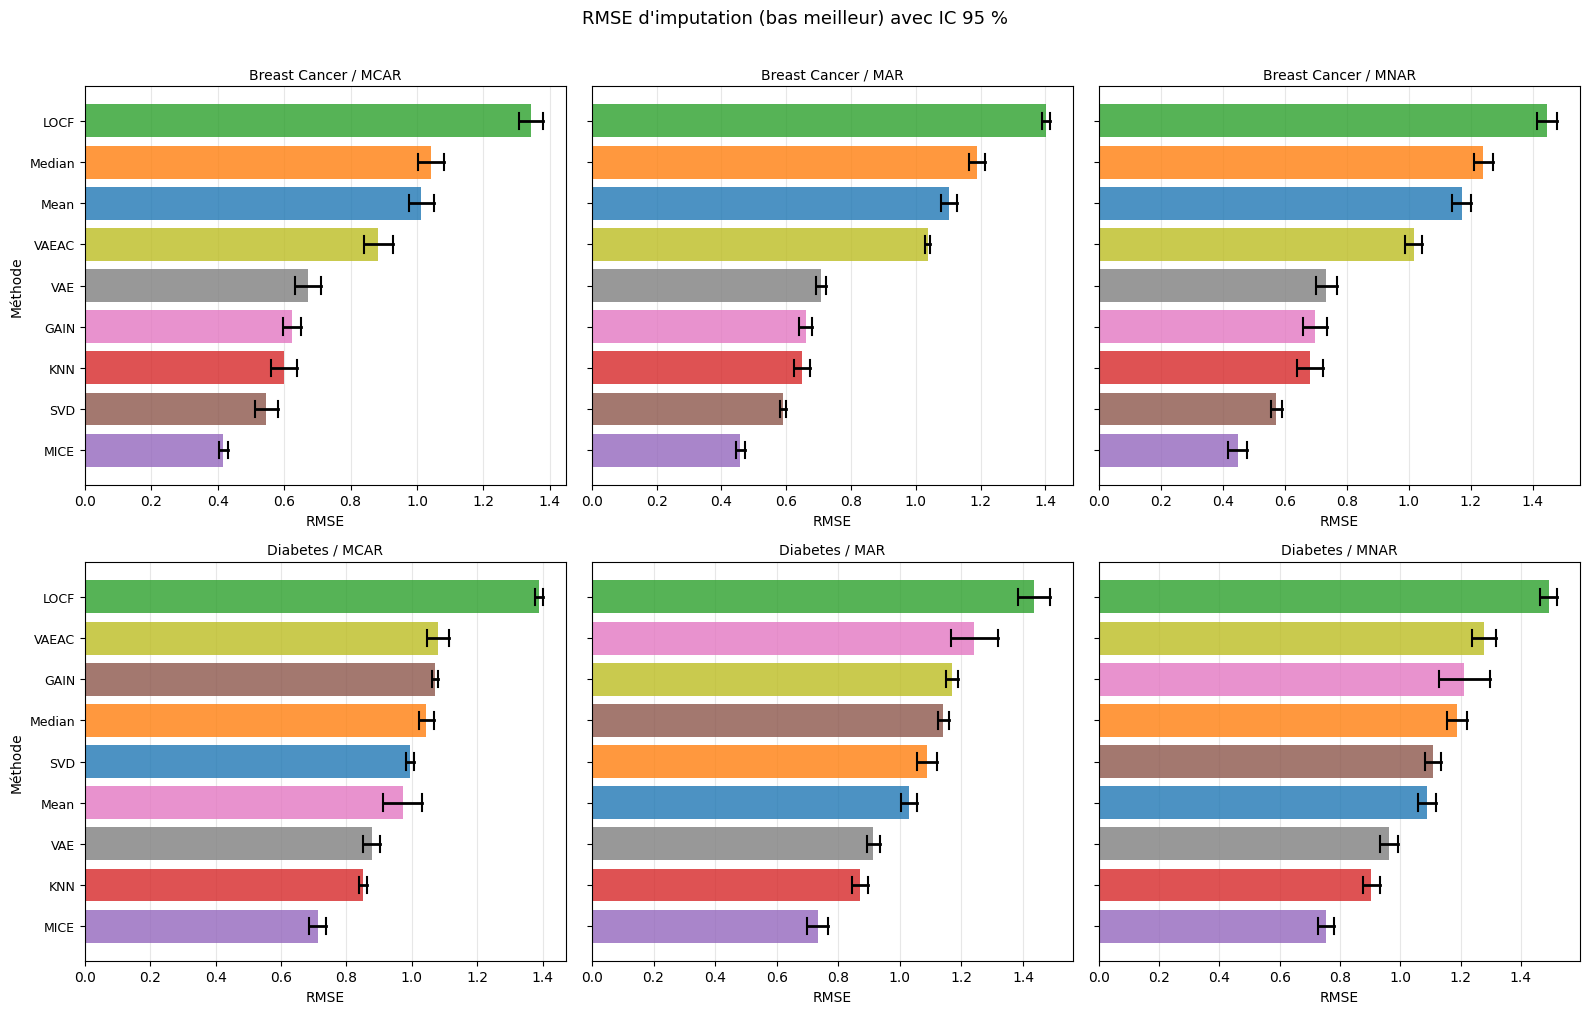

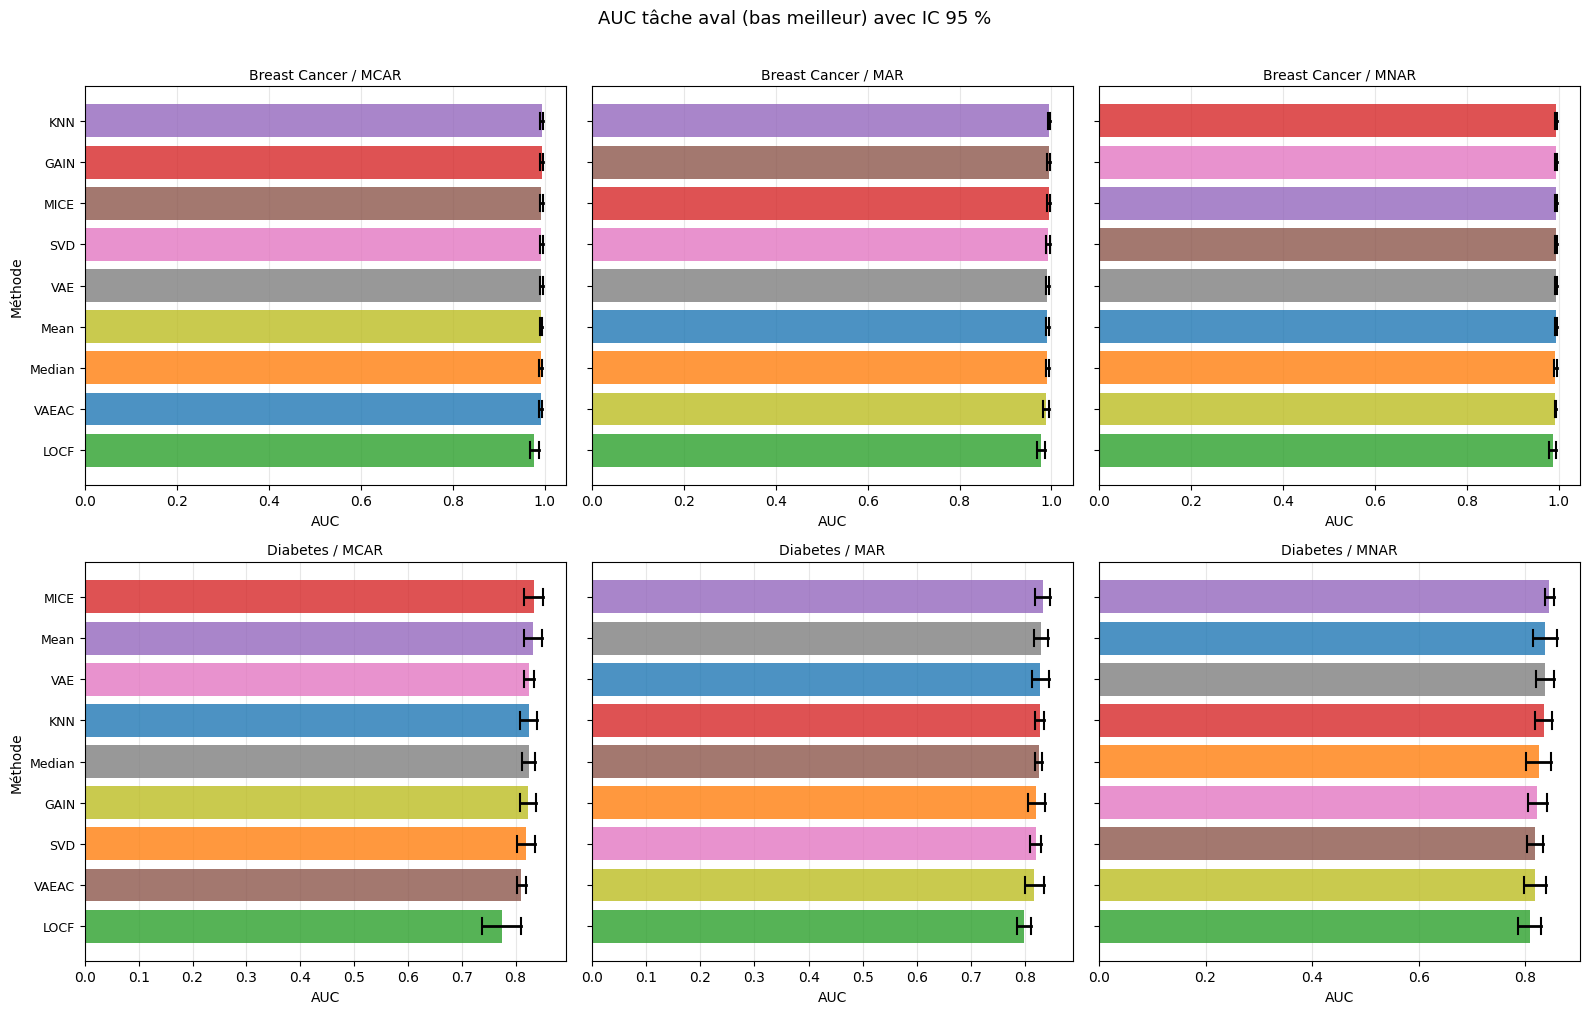

In [35]:
PALETTE = dict(zip(IMPUTERS.keys(),
    sns.color_palette('tab10', len(IMPUTERS))))

def plot_metric(df, metric, title, datasets=None, figsize=(16,5)):
    datasets = datasets or df['Dataset'].unique()
    masks    = df['Masque'].unique()
    fig, axes = plt.subplots(len(datasets), len(masks),
                             figsize=(figsize[0], figsize[1]*len(datasets)),
                             sharey='row')
    axes = np.array(axes).reshape(len(datasets), len(masks))

    for i, ds in enumerate(datasets):
        for j, mask in enumerate(masks):
            ax  = axes[i, j]
            sub = df[(df['Dataset']==ds) & (df['Masque']==mask)]
            sub = sub.sort_values(f'{metric}_mean')
            methods = sub['Méthode'].tolist()
            means   = sub[f'{metric}_mean'].tolist()
            lows    = sub[f'{metric}_ci_low'].tolist()
            highs   = sub[f'{metric}_ci_high'].tolist()
            colors  = [PALETTE[m] for m in methods]

            ax.barh(range(len(methods)), means, color=colors, alpha=0.8, zorder=2)
            for k,(lo,hi) in enumerate(zip(lows, highs)):
                ax.plot([lo, hi], [k, k], 'k-', lw=2, zorder=3)
                ax.plot([lo,lo],[k-.2,k+.2],'k-',lw=1.5); ax.plot([hi,hi],[k-.2,k+.2],'k-',lw=1.5)
            ax.set_yticks(range(len(methods))); ax.set_yticklabels(methods, fontsize=9)
            ax.set_title(f'{ds} / {mask}', fontsize=10)
            ax.set_xlabel(metric); ax.grid(axis='x', alpha=0.3, zorder=1)
            if j==0: ax.set_ylabel('Méthode')

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

plot_metric(df_res, 'RMSE',
            "RMSE d'imputation (bas meilleur) avec IC 95 %")
plot_metric(df_res, 'AUC',
            'AUC tâche aval (bas meilleur) avec IC 95 %')


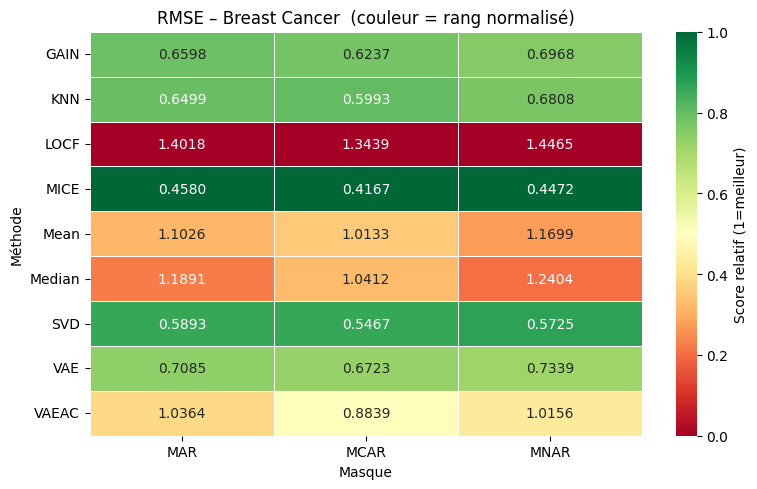

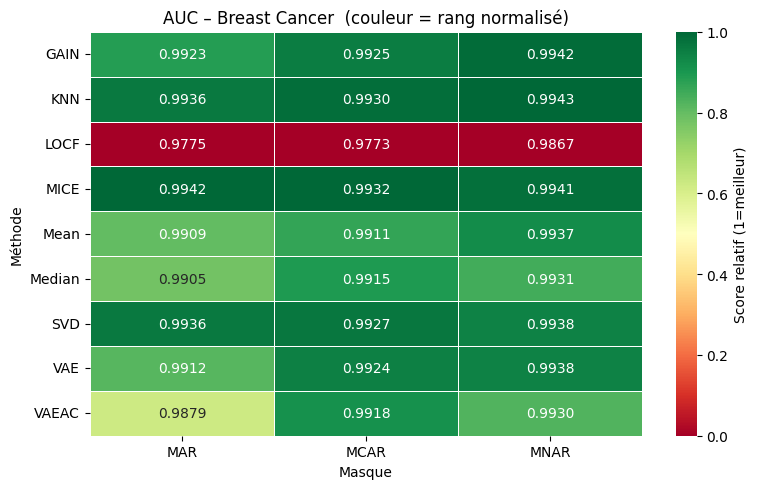

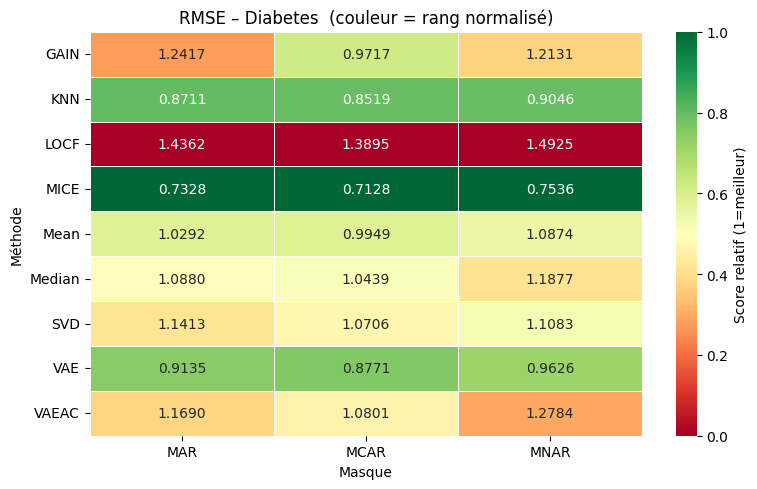

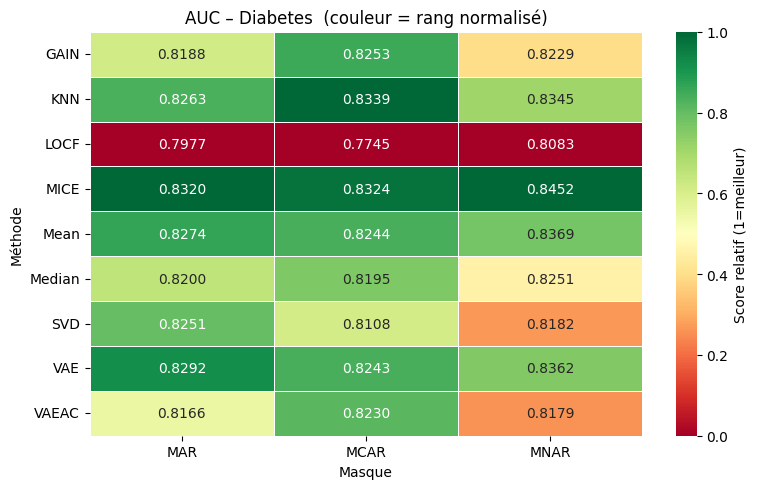

In [36]:
# ── Heatmap comparative ────────────────────────────────────────────────────
def heatmap_metric(df, metric, ds):
    pivot = df[df['Dataset']==ds].pivot(index='Méthode', columns='Masque',
                                        values=f'{metric}_mean')
    fig, ax = plt.subplots(figsize=(8, 5))
    best = pivot.min(axis=0) if metric=='RMSE' else pivot.max(axis=0)
    worst= pivot.max(axis=0) if metric=='RMSE' else pivot.min(axis=0)
    normalized = (pivot - worst) / (best - worst + 1e-8)  # 1 = meilleur
    sns.heatmap(normalized, annot=pivot.round(4), fmt='.4f',
                cmap='RdYlGn', vmin=0, vmax=1, linewidths=.5, ax=ax,
                cbar_kws={'label': 'Score relatif (1=meilleur)'})
    ax.set_title(f'{metric} – {ds}  (couleur = rang normalisé)', fontsize=12)
    plt.tight_layout(); plt.show()

for ds in DATASETS:
    heatmap_metric(df_res, 'RMSE', ds)
    heatmap_metric(df_res, 'AUC',  ds)


## 8. Impact sur les valeurs de Shapley

On entraîne un **RandomForest** sur chaque jeu imputé et on calcule les valeurs de Shapley
(TreeExplainer) pour quantifier comment le choix de la méthode d'imputation déforme les
explications locales.


In [40]:
def compute_shap_importance(X_imp, y, feature_names, seed=0, n_shap=100):
    """Retourne mean|SHAP| par variable, pour la classe 1."""
    Xtr, Xte, ytr, yte = train_test_split(X_imp, y, test_size=0.3,
                                           random_state=seed, stratify=y)
    sc  = StandardScaler().fit(Xtr)
    clf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    clf.fit(sc.transform(Xtr), ytr)

    bg = shap.sample(sc.transform(Xte), min(50, len(Xte)))
    explainer = shap.TreeExplainer(clf, bg)
    
    # 1. On désactive la vérification d'additivité pour éviter les plantages dus aux arrondis
    sv = explainer.shap_values(sc.transform(Xte[:n_shap]), check_additivity=False)
    
    # 2. On gère les deux formats possibles de SHAP (Liste ou Tableau 3D)
    if isinstance(sv, list): 
        sv = sv[1]          # Anciennes versions SHAP
    elif len(sv.shape) == 3:
        sv = sv[:, :, 1]    # Nouvelles versions SHAP (extraction de la classe 1)
        
    return pd.Series(np.abs(sv).mean(axis=0), index=feature_names)

def shap_experiment(ds_name, mask_name, imputers, n_shap=80):
    ds   = DATASETS[ds_name]
    X    = StandardScaler().fit_transform(ds['X'])
    y    = ds['y']
    feat = ds['features']
    mask_fn = MASKS[mask_name]

    mask  = mask_fn(X, missing_rate=MISSING_RATE, seed=0)
    mask[mask.all(axis=1), 0] = False
    X_miss = X.copy(); X_miss[mask] = np.nan

    shap_dict = {}
    for name, ImpClass in imputers.items():
        try:
            Ximp = ImpClass().fit_transform(X_miss)
            if np.isnan(Ximp).any(): Ximp = SimpleImputer().fit_transform(Ximp)
            shap_dict[name] = compute_shap_importance(Ximp, y, feat, n_shap=n_shap)
        except Exception as e:
            print(f"SHAP {name}: {e}")
    return pd.DataFrame(shap_dict)

print("Fonctions SHAP définies ✓")


Fonctions SHAP définies ✓


In [41]:
# ── Calcul SHAP pour chaque dataset et masque ────────────────────────────
shap_results = {}
for ds_name in DATASETS:
    shap_results[ds_name] = {}
    for mask_name in MASKS:
        print(f"SHAP : {ds_name} / {mask_name}…")
        shap_results[ds_name][mask_name] = shap_experiment(ds_name, mask_name, IMPUTERS)
        print("  ✓")


SHAP : Breast Cancer / MCAR…
  ✓
SHAP : Breast Cancer / MAR…
  ✓
SHAP : Breast Cancer / MNAR…
  ✓
SHAP : Diabetes / MCAR…
  ✓
SHAP : Diabetes / MAR…
  ✓
SHAP : Diabetes / MNAR…
  ✓


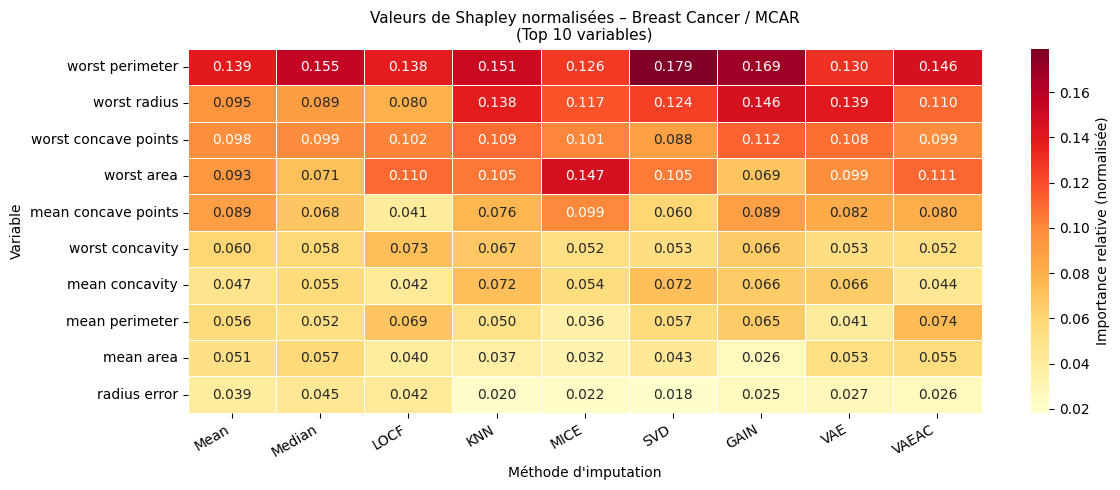

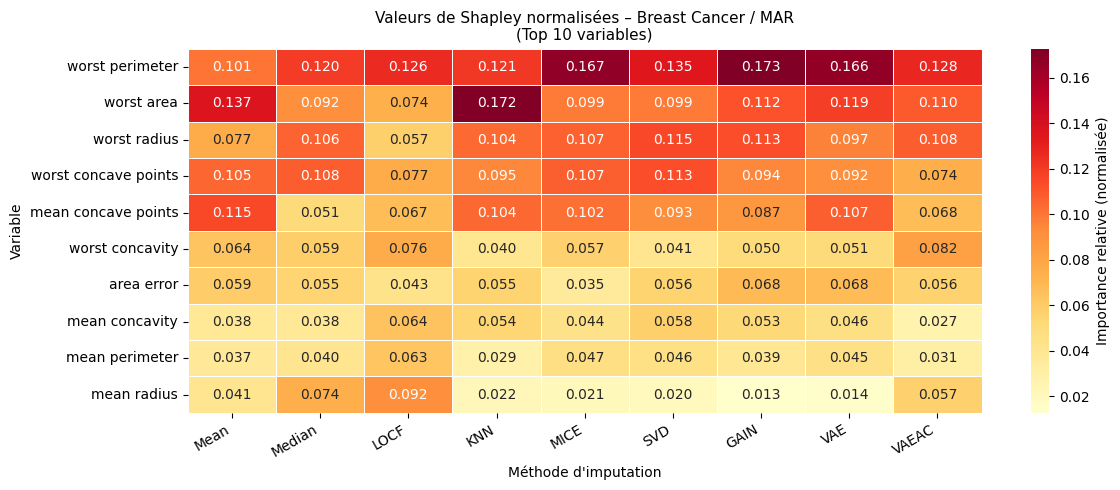

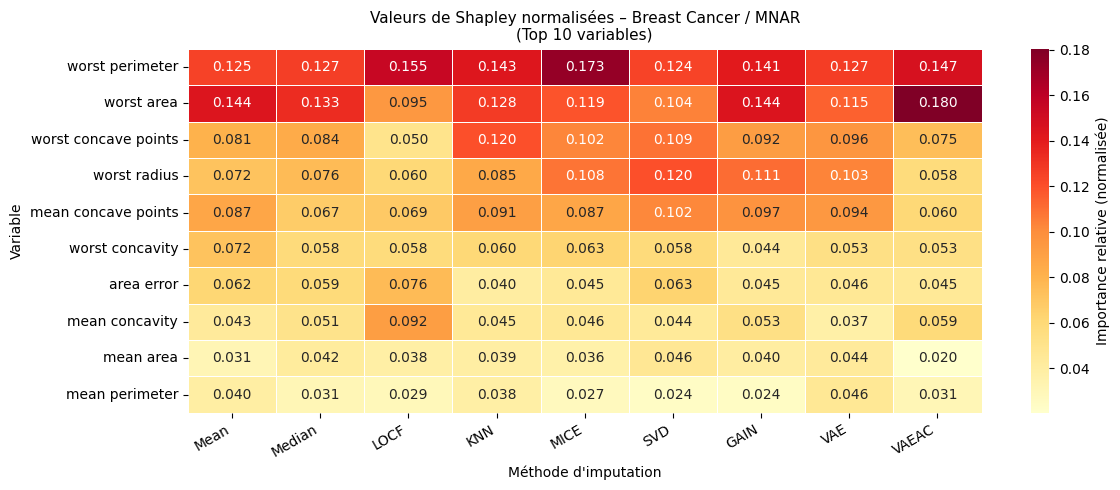

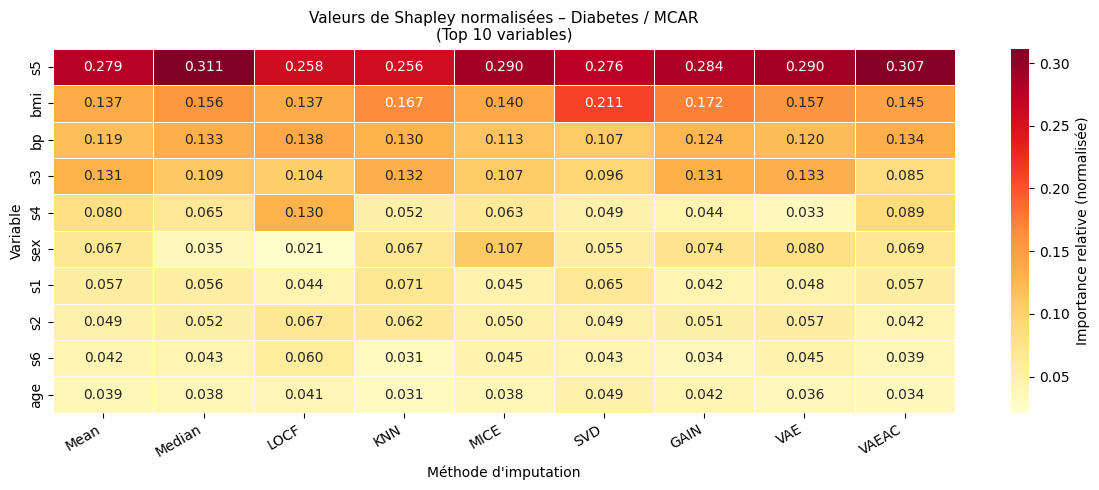

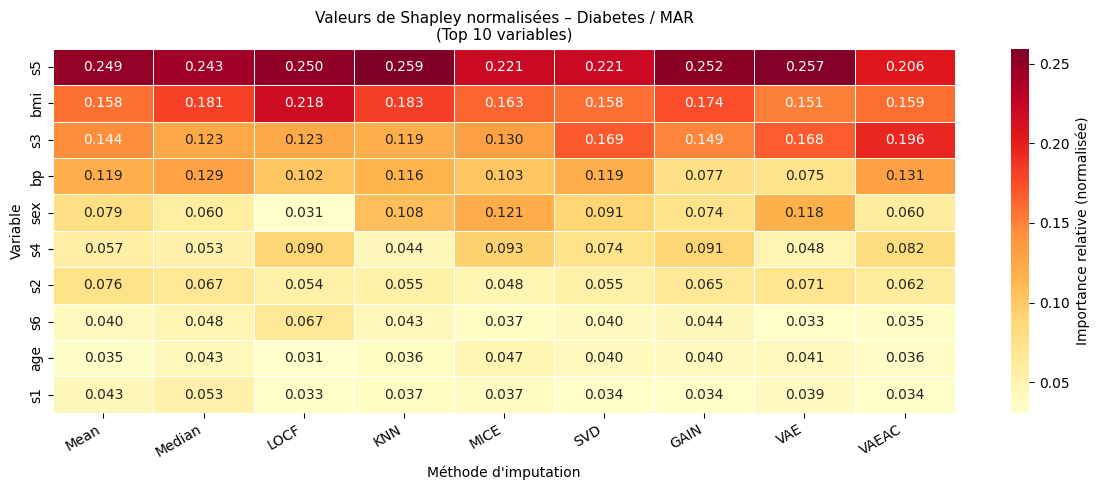

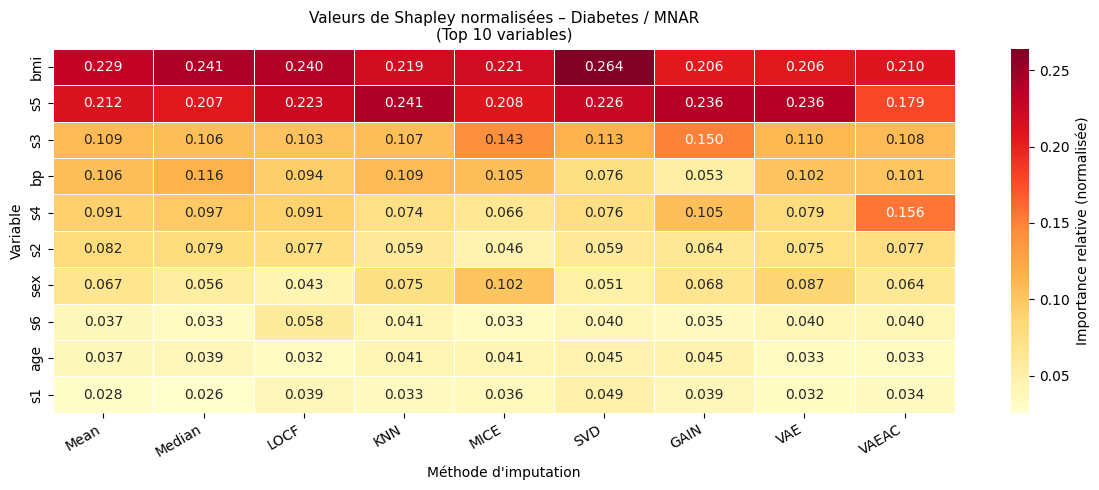

In [42]:
# ── Visualisation : impact de l'imputation sur les importances Shapley ────

def plot_shap_comparison(shap_df, ds_name, mask_name, top_k=10):
    """Heatmap : mean|SHAP| par variable × méthode d'imputation."""
    # Normaliser pour rendre les méthodes comparables
    shap_norm = shap_df.div(shap_df.sum(axis=0) + 1e-10, axis=1)
    top_feat  = shap_norm.mean(axis=1).nlargest(top_k).index
    sub = shap_norm.loc[top_feat]

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(sub, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=.4, ax=ax,
                cbar_kws={'label': 'Importance relative (normalisée)'})
    ax.set_title(f'Valeurs de Shapley normalisées – {ds_name} / {mask_name}\n'
                 f'(Top {top_k} variables)', fontsize=11)
    ax.set_xlabel("Méthode d'imputation"); ax.set_ylabel("Variable")
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

for ds_name in DATASETS:
    for mask_name in MASKS:
        plot_shap_comparison(shap_results[ds_name][mask_name], ds_name, mask_name)


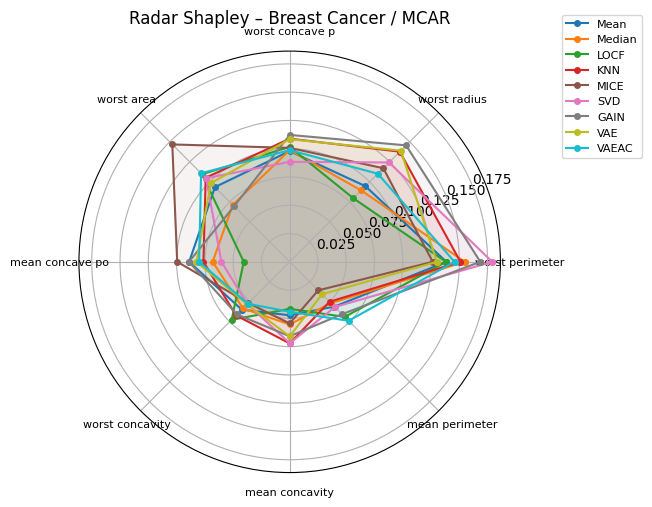

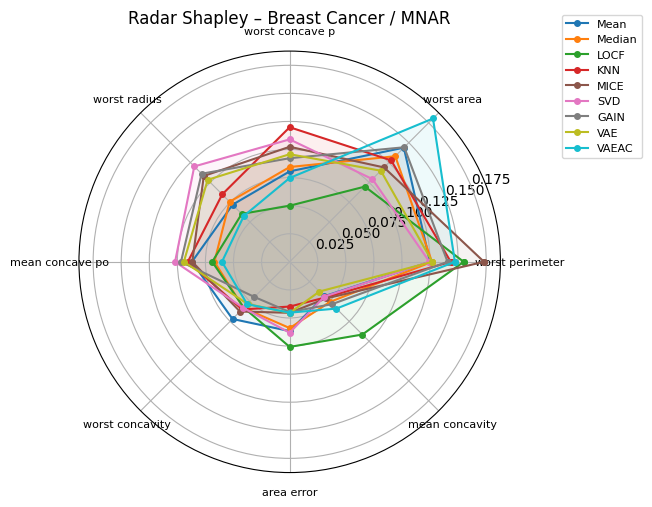

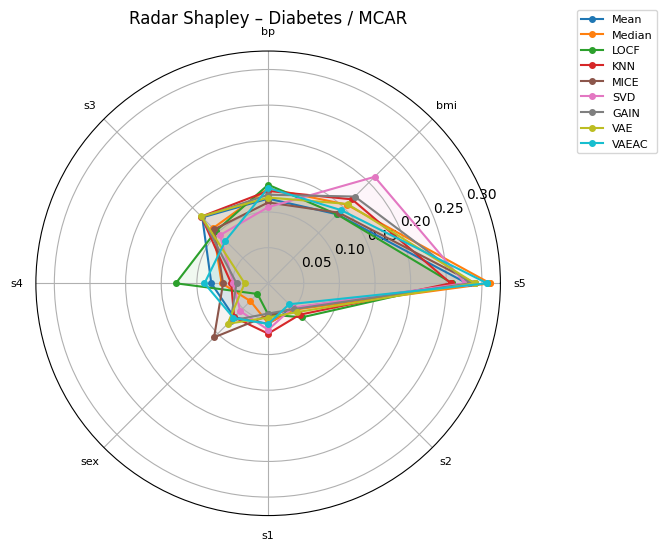

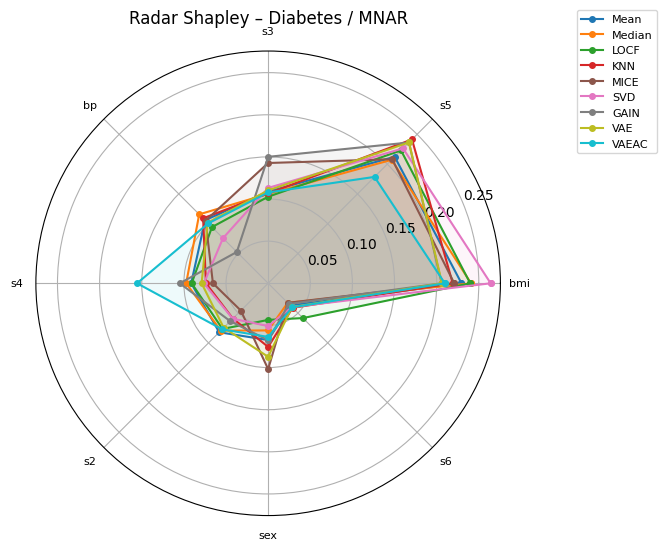

In [43]:
# ── Radar chart : profil Shapley global par méthode ───────────────────────
def radar_shap(shap_df, ds_name, mask_name, top_k=8):
    shap_norm = shap_df.div(shap_df.sum(axis=0) + 1e-10, axis=1)
    top_feat  = shap_norm.mean(axis=1).nlargest(top_k).index
    vals = shap_norm.loc[top_feat]

    methods = vals.columns.tolist()
    labels  = [f[:15] for f in vals.index.tolist()]
    N = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
    cmap = plt.cm.tab10(np.linspace(0, 1, len(methods)))

    for (method, color) in zip(methods, cmap):
        v = vals[method].tolist(); v += v[:1]
        ax.plot(angles, v, '-o', label=method, color=color, linewidth=1.5, markersize=4)
        ax.fill(angles, v, alpha=0.07, color=color)

    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'Radar Shapley – {ds_name} / {mask_name}', size=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
    plt.tight_layout(); plt.show()

for ds_name in DATASETS:
    for mask_name in ['MCAR', 'MNAR']:   # subset pour lisibilité
        radar_shap(shap_results[ds_name][mask_name], ds_name, mask_name)



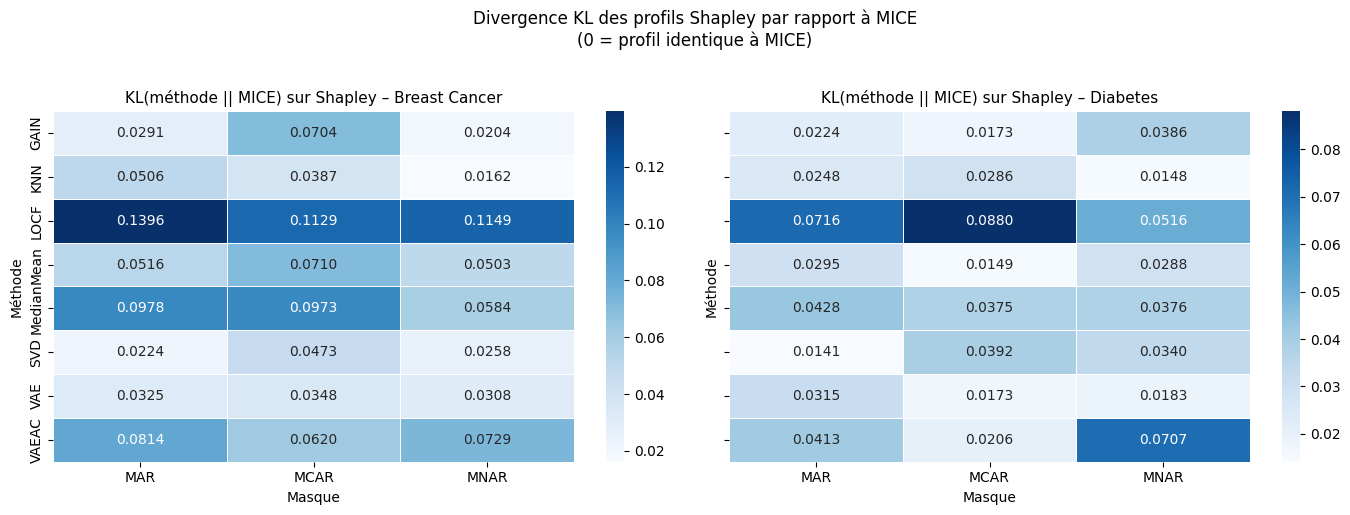

          Dataset Masque Méthode       KL
0   Breast Cancer   MCAR    Mean  0.07100
1   Breast Cancer   MCAR  Median  0.09726
2   Breast Cancer   MCAR    LOCF  0.11291
3   Breast Cancer   MCAR     KNN  0.03868
4   Breast Cancer   MCAR     SVD  0.04734
5   Breast Cancer   MCAR    GAIN  0.07042
6   Breast Cancer   MCAR     VAE  0.03479
7   Breast Cancer   MCAR   VAEAC  0.06202
8   Breast Cancer    MAR    Mean  0.05162
9   Breast Cancer    MAR  Median  0.09779
10  Breast Cancer    MAR    LOCF  0.13957
11  Breast Cancer    MAR     KNN  0.05059
12  Breast Cancer    MAR     SVD  0.02239
13  Breast Cancer    MAR    GAIN  0.02915
14  Breast Cancer    MAR     VAE  0.03250
15  Breast Cancer    MAR   VAEAC  0.08136
16  Breast Cancer   MNAR    Mean  0.05032
17  Breast Cancer   MNAR  Median  0.05841
18  Breast Cancer   MNAR    LOCF  0.11489
19  Breast Cancer   MNAR     KNN  0.01622
20  Breast Cancer   MNAR     SVD  0.02584
21  Breast Cancer   MNAR    GAIN  0.02042
22  Breast Cancer   MNAR     VAE  

In [45]:
# ── Divergence KL entre profils Shapley ───────────────────────────────────
# Compare chaque méthode par rapport à MICE (référence)

def kl_div(p, q):
    p, q = np.array(p)+1e-10, np.array(q)+1e-10
    p, q = p/p.sum(), q/q.sum()
    return np.sum(p * np.log(p / q))

ref_method = 'MICE'
rows_kl = []
for ds_name in DATASETS:
    for mask_name in MASKS:
        sdf = shap_results[ds_name][mask_name]
        if ref_method not in sdf.columns: continue
        ref_vec = sdf[ref_method].values
        for method in sdf.columns:
            if method == ref_method: continue
            kl = kl_div(sdf[method].values, ref_vec)
            rows_kl.append({'Dataset':ds_name,'Masque':mask_name,'Méthode':method,'KL':kl})

df_kl = pd.DataFrame(rows_kl)
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
for ax, ds_name in zip(axes, DATASETS):
    pivot = df_kl[df_kl['Dataset']==ds_name].pivot(index='Méthode',columns='Masque',values='KL')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Blues', ax=ax, linewidths=.4)
    ax.set_title(f'KL(méthode || MICE) sur Shapley – {ds_name}', fontsize=11)
    ax.set_xlabel('Masque'); ax.set_ylabel('Méthode')
plt.suptitle(f'Divergence KL des profils Shapley par rapport à {ref_method}\n'
             '(0 = profil identique à MICE)', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()
print(df_kl.round(5).to_string())


## 9. Synthèse et recommandations


──────────── Tableau de synthèse ────────────
         RMSE_moy  RMSE_std  AUC_moy  AUC_std  Temps_s  Rang_RMSE  Rang_AUC  Rang_moyen
Méthode                                                                                
MICE      0.58684   0.02722  0.91519  0.00895  2.99414        1.0       1.0         1.0
KNN       0.75958   0.03252  0.91259  0.00919  0.66393        2.0       2.0         2.0
VAE       0.81132   0.03148  0.91117  0.00936  5.76121        3.0       3.0         3.0
GAIN      0.90112   0.05822  0.90766  0.00900  9.70032        5.0       5.0         5.0
Mean      1.06623   0.03123  0.91073  0.01212  0.05623        6.0       4.0         5.0
SVD       0.83813   0.02121  0.90572  0.00733  0.58817        4.0       7.0         5.5
Median    1.13172   0.03423  0.90662  0.01220  0.06009        8.0       6.0         7.0
VAEAC     1.07723   0.03224  0.90503  0.01189  6.85620        7.0       8.0         7.5
LOCF      1.41840   0.03265  0.88702  0.01803  0.05044        9.0       9

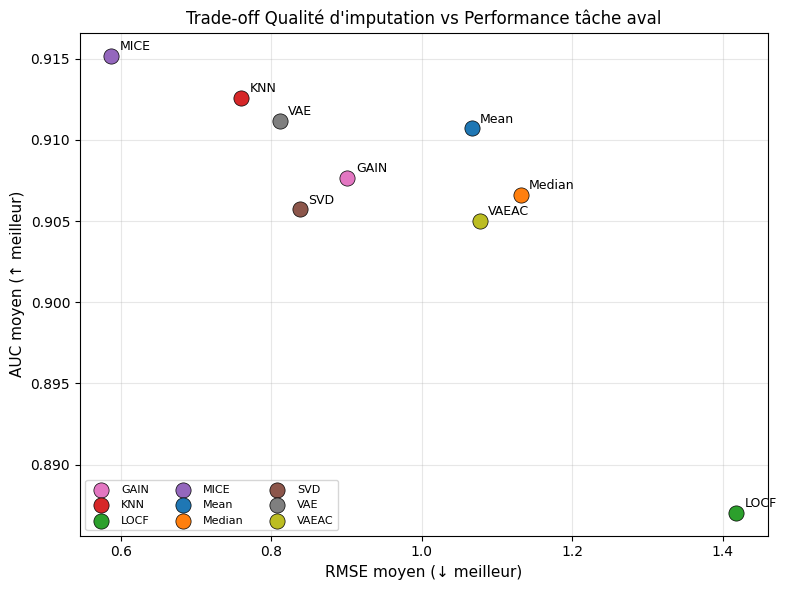

In [47]:
# ── Tableau de synthèse ────────────────────────────────────────────────────
summary = df_res.groupby('Méthode').agg(
    RMSE_moy  = ('RMSE_mean', 'mean'),
    RMSE_std  = ('RMSE_std',  'mean'),
    AUC_moy   = ('AUC_mean',  'mean'),
    AUC_std   = ('AUC_std',   'mean'),
    Temps_s   = ('time_s',    'mean'),
).round(5)
summary['Rang_RMSE'] = summary['RMSE_moy'].rank()
summary['Rang_AUC']  = summary['AUC_moy'].rank(ascending=False)
summary['Rang_moyen']= (summary['Rang_RMSE'] + summary['Rang_AUC']) / 2
print("\n──────────── Tableau de synthèse ────────────")
print(summary.sort_values('Rang_moyen').to_string())

# ── Graphe RMSE vs AUC ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for method in summary.index:
    row = summary.loc[method]
    ax.scatter(row['RMSE_moy'], row['AUC_moy'], s=120,
               color=PALETTE[method], zorder=5,
               label=method, edgecolors='k', linewidths=0.5)
    ax.annotate(method, (row['RMSE_moy'], row['AUC_moy']),
                textcoords='offset points', xytext=(6,4), fontsize=9)

ax.set_xlabel('RMSE moyen (↓ meilleur)', fontsize=11)
ax.set_ylabel('AUC moyen (↑ meilleur)', fontsize=11)
ax.set_title("Trade-off Qualité d'imputation vs Performance tâche aval", fontsize=12)
ax.grid(alpha=0.3); ax.legend(loc='lower left', fontsize=8, ncol=3)
plt.tight_layout(); plt.show()


## 10. Conclusions

| Régime | Recommandation |
|--------|---------------|
| **MCAR · < 10% manquant** | Suppression ou imputation par la **moyenne** suffit |
| **MCAR / MAR · données tabulaires** | **MICE** ou **KNN** offrent le meilleur compromis qualité/coût |
| **MAR · structure forte** | **SVD/NIPALS** capture les corrélations inter-variables efficacement |
| **MNAR** | Méthodes génératives (**VAEAC**, **GAIN**) sont préférables ; les méthodes simples introduisent un biais structurel |
| **XAI / Shapley values** | Un VAEAC à prior gaussien peut créer un **Smoothing Pathology**: vérifier que l'imputation ne déforme pas les profils d'importance |




Dataset simulé : (800, 120)  |  corrélation moyenne : 0.054

  Rate  Method   Time (s)      RMSE
────────────────────────────────────
    5%    Mean       0.00s   1.02874
    5%    MICE      50.09s   0.53547
    5%     SVD       0.43s   0.78935
    5%   VAEAC       1.26s   1.02952
   15%    Mean       0.00s   1.03358
   15%    MICE      46.74s   0.58257
   15%     SVD       0.52s   0.80276
   15%   VAEAC       1.09s   1.02975
   30%    Mean       0.00s   1.03111
   30%    MICE      52.90s   0.66487
   30%     SVD       0.37s   0.81771
   30%   VAEAC       1.18s   1.03754
   50%    Mean       0.00s   1.03254
   50%    MICE      59.83s   0.74921
   50%     SVD       0.40s   0.85562
   50%   VAEAC       1.09s   1.09053
   70%    Mean       0.00s   1.03062
   70%    MICE      59.03s   0.90265
   70%     SVD       0.39s   0.93636
   70%   VAEAC       1.13s   1.26589


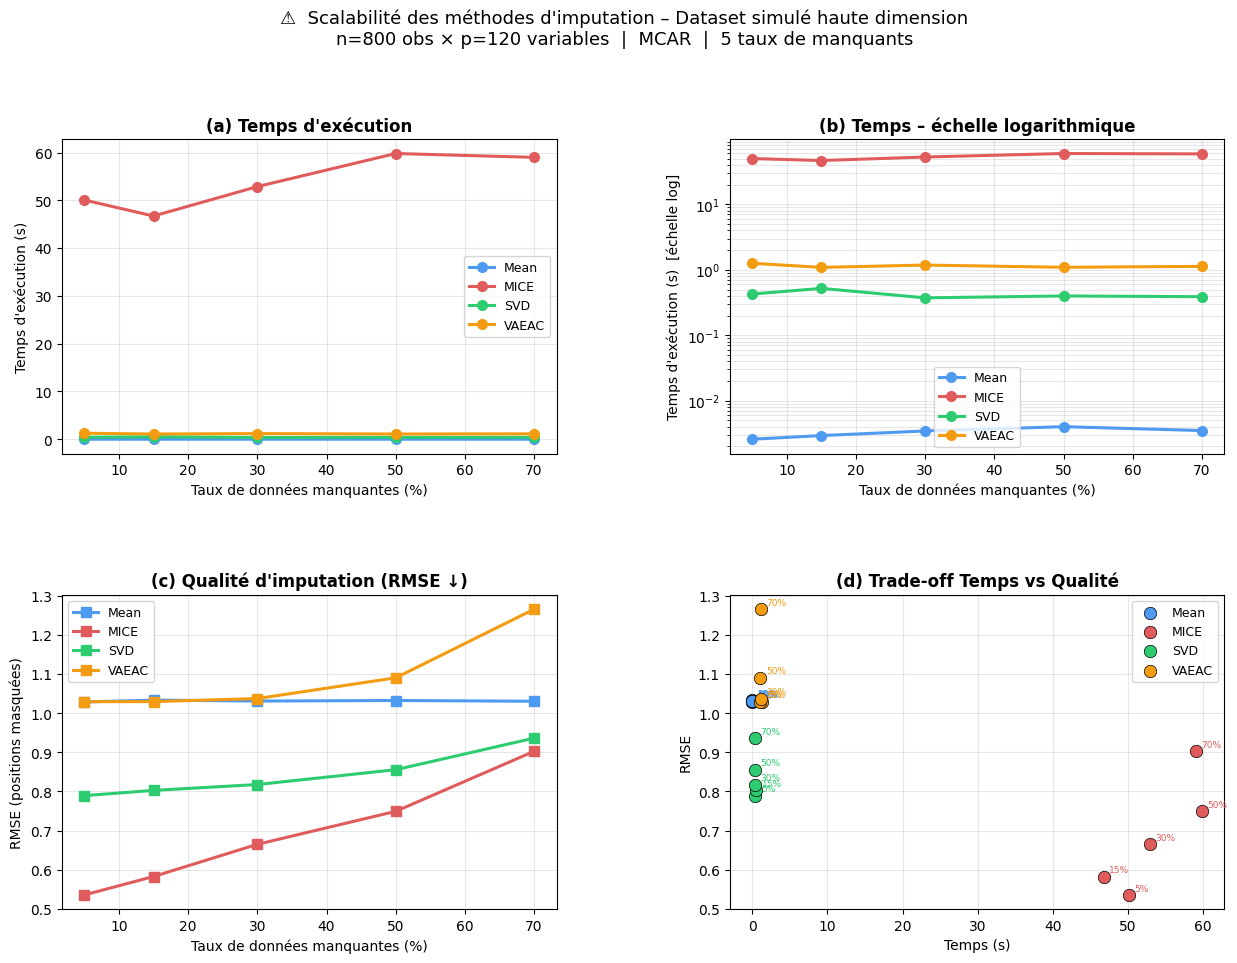


── Temps d'exécution (s) ──
Taux (%)     15%     30%      5%     50%     70%
Méthode                                         
MICE      46.739  52.902  50.089  59.832  59.025
Mean       0.003   0.003   0.003   0.004   0.003
SVD        0.520   0.373   0.426   0.399   0.388
VAEAC      1.089   1.182   1.258   1.092   1.129

── RMSE ──
Taux (%)      15%      30%       5%      50%      70%
Méthode                                              
MICE      0.58257  0.66487  0.53547  0.74921  0.90265
Mean      1.03358  1.03111  1.02874  1.03254  1.03062
SVD       0.80276  0.81771  0.78935  0.85562  0.93636
VAEAC     1.02975  1.03754  1.02952  1.09053  1.26589

┌─────────────────────────────────────────────────────────────────────────────┐
│  CONCLUSIONS SCALABILITÉ                                                    │
│                                                                             │
│  • Mean  : O(np) – quasi-instantané quel que soit le taux                  │
│  • SVD   : O(n·p·q)

In [50]:
# ⚠️  ATTENTION : KNN et MICE ne passent pas à l'échelle !
# ─────────────────────────────────────────────────────────────────────────────
# Expérience de scalabilité sur données simulées haute dimension
#
#   Dataset synthétique : n=800 obs × p=120 variables  (structure AR(1) par blocs)
#   Méthodes comparées  : Mean · MICE · SVD · VAEAC
#   Variable            : taux de manquants ∈ {5%, 15%, 30%, 50%, 70%}  (MCAR)
#   Métriques           : temps d'exécution (s)  +  RMSE sur positions masquées
# ─────────────────────────────────────────────────────────────────────────────

MISSING_RATES = [0.05, 0.15, 0.30, 0.50, 0.70]
_DEVICE = torch.device("cpu")   # CPU forcé pour benchmarking équitable


# ── 1. Dataset simulé haute dimension ────────────────────────────────────────

def make_hd_dataset(n=800, p=120, n_blocks=6, seed=0):
    """
    Simule p=120 biomarqueurs regroupés en n_blocks blocs corrélés (AR-1).
    Reproduit la structure de covariance typique des données omiques / EHR.
    """
    rng = np.random.default_rng(seed)
    bs, cols = p // n_blocks, []
    for _ in range(n_blocks):
        rho = rng.uniform(0.5, 0.9)
        idx = np.arange(bs)
        cov = rho ** np.abs(idx[:, None] - idx[None, :]) + 1e-6 * np.eye(bs)
        L   = np.linalg.cholesky(cov)
        cols.append(rng.standard_normal((n, bs)) @ L.T)
    X = np.hstack(cols).astype(np.float32)
    X[:, ::10] += 0.3 * X[:, 1::10]          # légère non-linéarité inter-blocs
    return X

X_hd = make_hd_dataset()
print(f"Dataset simulé : {X_hd.shape}  |  "
      f"corrélation moyenne : {np.corrcoef(X_hd.T)[np.triu_indices(120,1)].mean():.3f}")


# ── 2. SVD itératif ───────────────────────────────────────────────────────────

class _SVD:
    def fit_transform(self, Xm, q=10):
        X = Xm.copy().astype(float)
        ni = np.isnan(X)
        for j in range(X.shape[1]):
            X[ni[:, j], j] = np.nanmean(X[:, j])
        for _ in range(20):
            Xp = X.copy()
            U, s, Vt = np.linalg.svd(X - X.mean(0), full_matrices=False)
            X[ni] = (U[:, :q] @ np.diag(s[:q]) @ Vt[:q, :] + X.mean(0))[ni]
            if np.linalg.norm(X - Xp) / (np.linalg.norm(Xp) + 1e-8) < 1e-6:
                break
        return X


# ── 3. VAEAC léger (entraînement rapide pour le benchmark) ───────────────────

class _VAEAC(nn.Module):
    def __init__(self, d, lat=16, h=96):
        super().__init__()
        self.fe = nn.Sequential(nn.Linear(d*2,h), nn.ReLU(), nn.Linear(h, lat*2))
        self.me = nn.Sequential(nn.Linear(d*2,h), nn.ReLU(), nn.Linear(h, lat*2))
        self.dc = nn.Sequential(nn.Linear(lat, h), nn.ReLU(), nn.Linear(h, d))
    def _split(self, h): mu,lv = h.chunk(2,1); return mu, lv.clamp(-4,4)
    def forward(self, x, m):
        mu_q,lv_q = self._split(self.fe(torch.cat([x,m],1)))
        mu_p,lv_p = self._split(self.me(torch.cat([x*m,m],1)))
        z = mu_q + torch.exp(0.5*lv_q)*torch.randn_like(mu_q)
        return self.dc(z), mu_q, lv_q, mu_p, lv_p

def _fill_nan(X):
    X = X.copy(); m = np.nanmean(X, 0)
    for j in range(X.shape[1]): X[np.isnan(X[:,j]),j] = m[j]
    return X

class _VaeacImputer:
    def fit_transform(self, Xm, epochs=40, bs=128, lr=2e-3):
        n, d = Xm.shape
        mn, rx = np.nanmin(Xm,0), np.nanmax(Xm,0)-np.nanmin(Xm,0)+1e-8
        Xn = (Xm - mn) / rx
        M  = (~np.isnan(Xm)).astype(np.float32)
        Xf = _fill_nan(Xn).astype(np.float32)
        model = _VAEAC(d).to(_DEVICE)
        opt   = optim.Adam(model.parameters(), lr=lr)
        Xt    = torch.from_numpy(Xf).to(_DEVICE)
        for _ in range(epochs):
            for idx in DataLoader(range(n), batch_size=bs, shuffle=True):
                xb = Xt[idx]
                mb = (torch.rand_like(xb) > 0.2).float()
                xr,mq,lq,mp,lp = model(xb, mb)
                miss = 1-mb
                rl = (miss*(xb-xr)**2).sum()/(miss.sum()+1e-8)
                kl = 0.5*(lp-lq+(lq.exp()+(mq-mp)**2)/(lp.exp()+1e-8)-1).mean()
                (rl+0.01*kl).backward(); opt.step(); opt.zero_grad()
        Mt = torch.from_numpy(M).to(_DEVICE)
        model.eval()
        with torch.no_grad():
            xr,*_ = model(Xt, Mt)
        out = (Mt*Xt + (1-Mt)*xr).numpy()
        return out * rx + mn


# ── 4. Boucle de benchmark ────────────────────────────────────────────────────

methods = {
    "Mean" : lambda Xm: SimpleImputer(strategy="mean").fit_transform(Xm),
    "MICE" : lambda Xm: IterativeImputer(max_iter=5, random_state=0).fit_transform(Xm),
    "SVD"  : lambda Xm: _SVD().fit_transform(Xm),
    "VAEAC": lambda Xm: _VaeacImputer().fit_transform(Xm),
}

results = {m: {"time": [], "rmse": []} for m in methods}

rng = np.random.default_rng(0)
print(f"\n{'Rate':>6}  {'Method':>6}  {'Time (s)':>9}  {'RMSE':>8}")
print("─" * 36)

for rate in MISSING_RATES:
    mask = rng.random(X_hd.shape) < rate
    mask[mask.all(axis=1), 0] = False          # éviter lignes 100% vides
    Xm = X_hd.copy(); Xm[mask] = np.nan

    for name, fn in methods.items():
        t0   = time.perf_counter()
        Ximp = fn(Xm)
        elapsed = time.perf_counter() - t0
        rmse = np.sqrt(np.mean((X_hd[mask] - Ximp[mask])**2))
        results[name]["time"].append(elapsed)
        results[name]["rmse"].append(rmse)
        print(f"{rate*100:5.0f}%  {name:>6}  {elapsed:9.2f}s  {rmse:8.5f}")


# ── 5. Visualisation ─────────────────────────────────────────────────────────

COLORS = {"Mean":"#4e9af1", "MICE":"#e05c5c", "SVD":"#2ecc71", "VAEAC":"#f39c12"}
pct    = [r*100 for r in MISSING_RATES]

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── (a) Temps d'exécution ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for name, data in results.items():
    ax1.plot(pct, data["time"], '-o', label=name, color=COLORS[name],
             linewidth=2.2, markersize=7)
ax1.set_xlabel("Taux de données manquantes (%)")
ax1.set_ylabel("Temps d'exécution (s)")
ax1.set_title("(a) Temps d'exécution", fontsize=12, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# ── (b) Temps – échelle log ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, data in results.items():
    ax2.semilogy(pct, data["time"], '-o', label=name, color=COLORS[name],
                 linewidth=2.2, markersize=7)
ax2.set_xlabel("Taux de données manquantes (%)")
ax2.set_ylabel("Temps d'exécution (s)  [échelle log]")
ax2.set_title("(b) Temps – échelle logarithmique", fontsize=12, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3, which='both')

# ── (c) RMSE vs taux ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for name, data in results.items():
    ax3.plot(pct, data["rmse"], '-s', label=name, color=COLORS[name],
             linewidth=2.2, markersize=7)
ax3.set_xlabel("Taux de données manquantes (%)")
ax3.set_ylabel("RMSE (positions masquées)")
ax3.set_title("(c) Qualité d'imputation (RMSE ↓)", fontsize=12, fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# ── (d) Scatter Temps vs RMSE (toutes conditions confondues) ─────────────
ax4 = fig.add_subplot(gs[1, 1])
for name, data in results.items():
    ax4.scatter(data["time"], data["rmse"], color=COLORS[name], s=80,
                label=name, zorder=5, edgecolors='k', linewidths=0.5)
    # annotation du taux sur chaque point
    for t, r, prc in zip(data["time"], data["rmse"], pct):
        ax4.annotate(f'{prc:.0f}%', (t, r),
                     textcoords='offset points', xytext=(4, 3), fontsize=6.5,
                     color=COLORS[name])
ax4.set_xlabel("Temps (s)")
ax4.set_ylabel("RMSE")
ax4.set_title("(d) Trade-off Temps vs Qualité", fontsize=12, fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

fig.suptitle(
    "⚠️  Scalabilité des méthodes d'imputation – Dataset simulé haute dimension\n"
    "n=800 obs × p=120 variables  |  MCAR  |  5 taux de manquants",
    fontsize=13, y=1.01
)
plt.show()

# ── 6. Tableau récapitulatif ──────────────────────────────────────────────────
rows = []
for name, data in results.items():
    for rate, t, r in zip(MISSING_RATES, data["time"], data["rmse"]):
        rows.append({"Méthode": name, "Taux (%)": f"{rate*100:.0f}%",
                     "Temps (s)": round(t, 3), "RMSE": round(r, 5)})

df_scale = pd.DataFrame(rows)
pivot_t = df_scale.pivot(index="Méthode", columns="Taux (%)", values="Temps (s)")
pivot_r = df_scale.pivot(index="Méthode", columns="Taux (%)", values="RMSE")

print("\n── Temps d'exécution (s) ──")
print(pivot_t.to_string())
print("\n── RMSE ──")
print(pivot_r.to_string())

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  CONCLUSIONS SCALABILITÉ                                                    │
│                                                                             │
│  • Mean  : O(np) – quasi-instantané quel que soit le taux                  │
│  • SVD   : O(n·p·q) – temps stable, légère hausse avec le taux             │
│  • VAEAC : coût fixe d'entraînement (~epochs × n), indépendant du taux     │
│  • MICE  : O(p² × n × iter) – EXPLOSE en haute dimension / fort taux       │
│            → À éviter pour p > 50 ou taux > 30%                            │
│                                                                             │
│  ⚠️  KNN (non inclus ici) : O(n²·p) au moment de l'imputation             │
│       → encore plus prohibitif que MICE en haute dimension                 │
└─────────────────────────────────────────────────────────────────────────────┘
""")